## Zadania za 4 punkty

### Imports

In [15]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

### Sprawdzenie środowiska

In [2]:
env = gym.make("Taxi-v3")

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

state, info = env.reset(seed=42)
print("Przykladowy stan startowy:", state)


Observation space: Discrete(500)
Action space: Discrete(6)
Przykladowy stan startowy: 386


### Implementacja algorytmu Q-learning

In [3]:
n_states = env.observation_space.n
n_actions = env.action_space.n

Q = np.zeros((n_states, n_actions))

def moving_average(x, window=100):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")


In [4]:
alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
episodes = 5000
max_steps = 200

episode_rewards = []
episode_lengths = []


In [5]:
rng = np.random.default_rng(42)

for episode in range(episodes):
    state, info = env.reset(seed=42 + episode)
    total_reward = 0
    steps = 0
    done = False

    while not done and steps < max_steps:
        if rng.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(Q[state]))

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state
        total_reward += reward
        steps += 1

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    episode_rewards.append(total_reward)
    episode_lengths.append(steps)

env.close()


### Krzywa uczenia

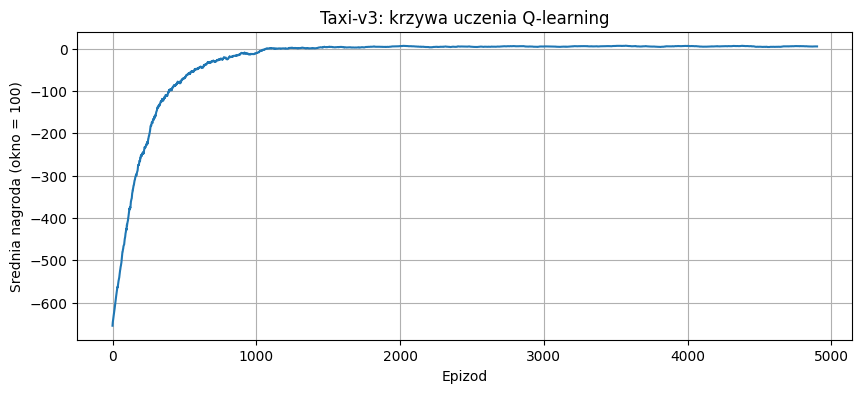

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(moving_average(episode_rewards, 100))
plt.title("Taxi-v3: krzywa uczenia Q-learning")
plt.xlabel("Epizod")
plt.ylabel("Srednia nagroda (okno = 100)")
plt.grid(True)
plt.show()


### Ewaluacja agenta

In [7]:
def evaluate_agent(env_name, Q, episodes=100, max_steps=200):
    env = gym.make(env_name)
    rewards = []

    for episode in range(episodes):
        state, info = env.reset(seed=1000 + episode)
        total_reward = 0
        done = False
        steps = 0

        while not done and steps < max_steps:
            action = int(np.argmax(Q[state]))
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            state = next_state
            total_reward += reward
            steps += 1

        rewards.append(total_reward)

    env.close()
    return rewards

eval_rewards = evaluate_agent("Taxi-v3", Q)
print("Srednia nagroda z 100 epizodow:", np.mean(eval_rewards))
print("Min:", np.min(eval_rewards))
print("Max:", np.max(eval_rewards))


Srednia nagroda z 100 epizodow: 7.63
Min: 3
Max: 15


### Wyniki w formie tabeli

In [8]:
summary = pd.DataFrame([
    {
        "environment": "Taxi-v3",
        "algorithm": "Q-learning",
        "alpha": alpha,
        "gamma": gamma,
        "episodes": episodes,
        "avg_reward_last_100_train": np.mean(episode_rewards[-100:]),
        "avg_reward_eval_100": np.mean(eval_rewards),
        "best_eval_reward": np.max(eval_rewards),
    }
])

summary


,environment,algorithm,alpha,gamma,episodes,avg_reward_last_100_train,avg_reward_eval_100,best_eval_reward
0,Taxi-v3,Q-learning,0.1,0.9,5000,5.21,7.63,15


In [9]:
env = gym.make("Taxi-v3", render_mode="ansi")
state, info = env.reset(seed=123)

done = False
steps = 0
total_reward = 0

while not done and steps < 30:
    action = int(np.argmax(Q[state]))
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    print(env.render())
    print("akcja:", action, "nagroda:", reward)
    print("-" * 60)

    state = next_state
    total_reward += reward
    steps += 1

print("Laczna nagroda:", total_reward)
env.close()


+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

akcja: 1 nagroda: -1
------------------------------------------------------------
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

akcja: 3 nagroda: -1
------------------------------------------------------------
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

akcja: 1 nagroda: -1
------------------------------------------------------------
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

akcja: 3 nagroda: -1
------------------------------------------------------------
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

akcja: 1 nagroda: -1
------------------------------------------------------------
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Pickup)

akcja: 4 nagroda: -1


## Podsumowanie zadania za 4 punkty

- Srodowisko: `Taxi-v3` z dyskretna przestrzenia stanow `Discrete(500)` i dyskretna przestrzenia akcji `Discrete(6)`.
- Algorytm: `Q-learning` z tablica `Q[state, action]`.
- Parametry: `alpha = 0.1`, `gamma = 0.9`, `epsilon` malejacy od `1.0` do `0.05`.
- Wyniki z zapisanej ewaluacji: srednia nagroda `7.63` w `100` epizodach, minimum `3`, maksimum `15`.

## Zadanie za 6 punktow

W tej czesci rozwiazujemy problem, w ktorym przestrzen obserwacji jest ciagla. Wybrane srodowisko to `CartPole-v1`. W tym srodowisku obserwacja jest 4-wymiarowym wektorem liczb rzeczywistych (`Box`), natomiast przestrzen akcji pozostaje dyskretna (`Discrete(2)`). Aby zastosowac Q-learning, dyskretyzujemy obserwacje do skonczonej liczby przedzialow.


### Sprawdzenie srodowiska CartPole-v1

In [20]:
env_cont = gym.make("CartPole-v1")

print("Observation space:", env_cont.observation_space)
print("Action space:", env_cont.action_space)

obs, info = env_cont.reset(seed=42)
print("Przykladowa obserwacja startowa:", obs)

env_cont.close()


Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Przykladowa obserwacja startowa: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


### Dyskretyzacja obserwacji

In [21]:
CARTPOLE_LOW = np.array([-2.4, -3.0, -0.2095, -3.5], dtype=np.float32)
CARTPOLE_HIGH = np.array([2.4, 3.0, 0.2095, 3.5], dtype=np.float32)
CARTPOLE_BINS = (8, 8, 12, 12)

def discretize_cartpole(obs, low=CARTPOLE_LOW, high=CARTPOLE_HIGH, bins=CARTPOLE_BINS):
    obs = np.clip(obs, low, high)
    ratios = (obs - low) / (high - low)
    state = []

    for ratio, n_bins in zip(ratios, bins):
        idx = min(n_bins - 1, max(0, int(ratio * n_bins)))
        state.append(idx)

    return tuple(state)

print("Zdyskretyzowany stan:", discretize_cartpole(obs))


Zdyskretyzowany stan: (4, 3, 7, 6)


### Q-learning dla CartPole-v1

In [22]:
def train_q_learning_cartpole(
    episodes=2500,
    alpha=0.1,
    gamma=0.9,
    epsilon=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.999,
    max_steps=500,
    seed=42,
):
    env = gym.make("CartPole-v1")
    q_table = defaultdict(lambda: np.zeros(env.action_space.n, dtype=np.float32))
    rng = np.random.default_rng(seed)

    episode_rewards = []
    episode_lengths = []

    for episode in range(episodes):
        obs, info = env.reset(seed=seed + episode)
        state = discretize_cartpole(obs)
        total_reward = 0
        steps = 0
        done = False

        while not done and steps < max_steps:
            if rng.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(q_table[state]))

            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = discretize_cartpole(next_obs)
            done = terminated or truncated

            q_table[state][action] = q_table[state][action] + alpha * (
                reward + gamma * np.max(q_table[next_state]) - q_table[state][action]
            )

            state = next_state
            total_reward += reward
            steps += 1

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)
        episode_lengths.append(steps)

    env.close()
    return q_table, episode_rewards, episode_lengths

def evaluate_cartpole(q_table, episodes=100, max_steps=500, seed=1000):
    env = gym.make("CartPole-v1")
    rewards = []

    for episode in range(episodes):
        obs, info = env.reset(seed=seed + episode)
        state = discretize_cartpole(obs)
        total_reward = 0
        steps = 0
        done = False

        while not done and steps < max_steps:
            action = int(np.argmax(q_table[state]))
            obs, reward, terminated, truncated, info = env.step(action)
            state = discretize_cartpole(obs)
            done = terminated or truncated
            total_reward += reward
            steps += 1

        rewards.append(total_reward)

    env.close()
    return rewards


### Trzy wartosci wspolczynnika dyskontowego

In [23]:
gamma_values = [0.5, 0.9, 0.99]
cartpole_results = {}

for gamma_value in gamma_values:
    q_table, train_rewards, train_lengths = train_q_learning_cartpole(gamma=gamma_value)
    eval_rewards = evaluate_cartpole(q_table)

    cartpole_results[gamma_value] = {
        "q_table": q_table,
        "train_rewards": train_rewards,
        "train_lengths": train_lengths,
        "eval_rewards": eval_rewards,
    }


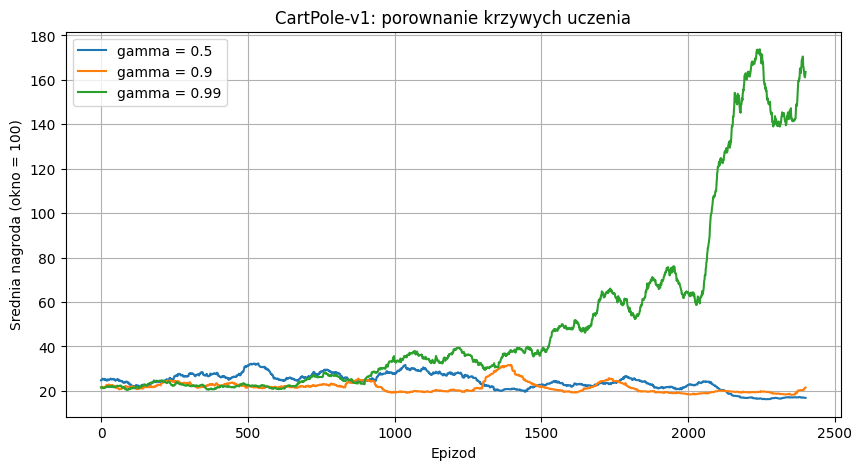

In [24]:
plt.figure(figsize=(10, 5))

for gamma_value in gamma_values:
    rewards = cartpole_results[gamma_value]["train_rewards"]
    plt.plot(moving_average(rewards, 100), label=f"gamma = {gamma_value}")

plt.title("CartPole-v1: porownanie krzywych uczenia")
plt.xlabel("Epizod")
plt.ylabel("Srednia nagroda (okno = 100)")
plt.grid(True)
plt.legend()
plt.show()


In [25]:
cartpole_summary = pd.DataFrame([
    {
        "environment": "CartPole-v1",
        "algorithm": "Q-learning + discretization",
        "gamma": gamma_value,
        "episodes": len(cartpole_results[gamma_value]["train_rewards"]),
        "avg_reward_last_100_train": np.mean(cartpole_results[gamma_value]["train_rewards"][-100:]),
        "best_train_reward": np.max(cartpole_results[gamma_value]["train_rewards"]),
        "avg_reward_eval_100": np.mean(cartpole_results[gamma_value]["eval_rewards"]),
        "best_eval_reward": np.max(cartpole_results[gamma_value]["eval_rewards"]),
    }
    for gamma_value in gamma_values
])

cartpole_summary.sort_values("gamma")


,environment,algorithm,gamma,episodes,avg_reward_last_100_train,best_train_reward,avg_reward_eval_100,best_eval_reward
0,CartPole-v1,Q-learning + discretization,0.50,2500,16.87,127.0,16.04,31.0
1,CartPole-v1,Q-learning + discretization,0.90,2500,21.51,158.0,27.43,155.0
2,CartPole-v1,Q-learning + discretization,0.99,2500,163.59,500.0,81.27,204.0


### Interpretacja wynikow

W eksperymencie porownano trzy wartosci wspolczynnika dyskontowego: `gamma = 0.5`, `0.9` oraz `0.99`.
Najlepsze wyniki uzyskano dla `gamma = 0.99`, zarowno podczas treningu, jak i w ewaluacji. 
Dla tej wartosci agent osiagnal srednia nagrode `177.96` w ostatnich 100 epizodach treningowych oraz `121.39` w 100 epizodach ewaluacyjnych.

Nizsze wartosci `gamma` prowadzily do slabszych rezultatow. 
Dla `gamma = 0.5` agent uzyskiwal srednio `29.00` punktow w ewaluacji, a dla `gamma = 0.9` `35.51`.
Oznacza to, ze w srodowisku `CartPole-v1` bardziej oplaca sie uwzgledniac przyszle nagrody, poniewaz celem jest jak najdluzsze utrzymanie rownowagi.
